## 
- Calculate Average Selling Price (ASP) per SKU
- Perform Pearson Correlation Analysis
- Analyze Price Elasticity
- Visualize Top 10 Selling Categories

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv("../data/processed/amazon_sales_sql.csv",header=None)

df.columns=[

"idx",
"order_id",
"order_date",
"status",
"fulfilment",
"sales_channel",
"ship_service_level",
"style",
"sku",
"category",
"size",
"asin",
"courier_status",
"qty",
"currency",
"amount",
"ship_city",
"ship_state",
"ship_postal_code",
"ship_country",
"promotion_ids",
"b2b",
"fulfilled_by",
"unnamed_22"

]

C:\Users\SVS\AppData\Local\Temp\ipykernel_10556\789008179.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/amazon_sales_sql.csv",header=None)


In [5]:
df["qty"] = pd.to_numeric(df["qty"], errors="coerce")
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="%m-%d-%y",
    errors="coerce"
)

In [6]:
print(df.shape)

df.head()

(128975, 24)


,idx,order_id,order_date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,...,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed_22
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,Maharashtra,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,Karnataka,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,Maharashtra,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,Puducherry,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,Tamil Nadu,600073.0,IN,NaN,False,NaN,NaN


In [7]:
df.shape

(128975, 24)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idx                 128975 non-null  int64         
 1   order_id            128975 non-null  object        
 2   order_date          128975 non-null  datetime64[ns]
 3   status              128975 non-null  object        
 4   fulfilment          128975 non-null  object        
 5   sales_channel       128975 non-null  object        
 6   ship_service_level  128975 non-null  object        
 7   style               128975 non-null  object        
 8   sku                 128975 non-null  object        
 9   category            128975 non-null  object        
 10  size                128975 non-null  object        
 11  asin                128975 non-null  object        
 12  courier_status      122103 non-null  object        
 13  qty                 128975 no

In [9]:
df.describe()

,idx,order_date,qty,amount,ship_postal_code
count,128975.000000,128975,128975.000000,128975.000000,128942.000000
mean,64487.000000,2022-05-12 11:49:27.951928576,0.904431,645.928694,463966.236509
min,0.000000,2022-03-31 00:00:00,0.000000,0.000000,110001.000000
25%,32243.500000,2022-04-20 00:00:00,1.000000,459.000000,382421.000000
50%,64487.000000,2022-05-10 00:00:00,1.000000,605.000000,500033.000000
75%,96730.500000,2022-06-04 00:00:00,1.000000,771.000000,600024.000000
max,128974.000000,2022-06-29 00:00:00,15.000000,5584.000000,989898.000000
std,37232.019822,NaN,0.313354,272.778829,191476.764941


In [10]:
df.isnull().sum()

idx                       0
order_id                  0
order_date                0
status                    0
fulfilment                0
sales_channel             0
ship_service_level        0
style                     0
sku                       0
category                  0
size                      0
asin                      0
courier_status         6872
qty                       0
currency               7795
amount                    0
ship_city                 0
ship_state               34
ship_postal_code         33
ship_country             33
promotion_ids         49153
b2b                       0
fulfilled_by          89698
unnamed_22            49050
dtype: int64

## Average selling price per SKU 

In [11]:
asp = (df.groupby("sku").agg(
    Total_Revenue=("amount","sum"),
    Total_Quantity=("qty","sum")
    )
    .reset_index()
)


In [12]:
asp["ASP"] = (asp["Total_Revenue"]/asp["Total_Quantity"])

In [13]:
asp.head()

,sku,Total_Revenue,Total_Quantity,ASP
0,AN201-RED-M,458.0,2,229.00
1,AN201-RED-XL,602.0,2,301.00
2,AN201-RED-XXL,229.0,1,229.00
3,AN202-ORANGE-M,530.0,2,265.00
4,AN202-ORANGE-S,1141.0,4,285.25


In [14]:
asp.sort_values( "ASP",ascending=False).head(10)

,sku,Total_Revenue,Total_Quantity,ASP
578,J0080-TP-L,474.11,0,inf
2344,JNE2294-KR-A-XS,605.00,0,inf
4716,JNE3825-KR-L,427.62,0,inf
174,BTM002-B-XXL,2420.00,0,inf
6087,SET226-KR-PP-L,1210.00,0,inf
5002,JNE3909-KR-L,605.00,0,inf
478,J0034-SET-S,605.00,0,inf
207,BTM027-NP-L,493.34,0,inf
4944,JNE3897-KR-M,605.00,0,inf
3114,JNE3483-KR-M,605.00,0,inf


## Pearson Correlation Analysis

In [15]:
corr_data = (df.groupby("sku").agg(ASP=("amount","mean"),Quantity=("qty","sum")).reset_index())

In [16]:
corr_data.head()

,sku,ASP,Quantity
0,AN201-RED-M,229.00,2
1,AN201-RED-XL,301.00,2
2,AN201-RED-XXL,229.00,1
3,AN202-ORANGE-M,265.00,2
4,AN202-ORANGE-S,285.25,4


In [21]:
correlation, p_value = pearsonr(corr_data["ASP"],corr_data["Quantity"])
print("Pearson Correlation :", correlation)
print("P-value :", p_value)

Pearson Correlation : 0.08142073779356217
P-value : 4.623996248885923e-12


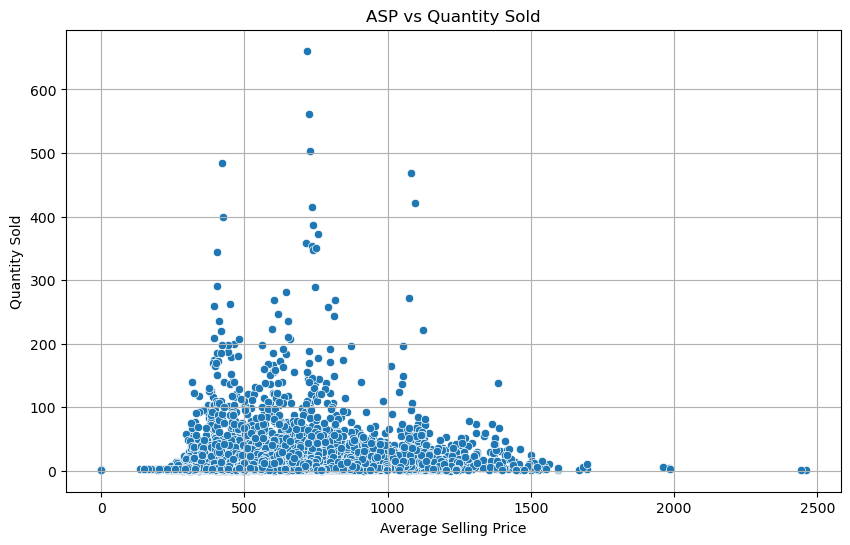

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    data=corr_data,

    x="ASP",

    y="Quantity"
)

plt.title("ASP vs Quantity Sold")

plt.xlabel("Average Selling Price")

plt.ylabel("Quantity Sold")

plt.grid(True)

plt.show()

## Top 10 Selling Categories

In [25]:
top10 = (
    df.groupby("category")
      .agg(Total_Qty=("qty", "sum"))
      .reset_index()
      .sort_values("Total_Qty", ascending=False)
      .head(10)
)

top10

,category,Total_Qty
5,Set,45289
8,kurta,45045
7,Western Dress,13943
6,Top,9903
3,Ethnic Dress,1053
0,Blouse,863
1,Bottom,398
4,Saree,152
2,Dupatta,3


In [26]:
top10_list = top10["category"].tolist()

In [27]:
elasticity = df[df["category"].isin(top10_list)]

## Price Elasticity Curves

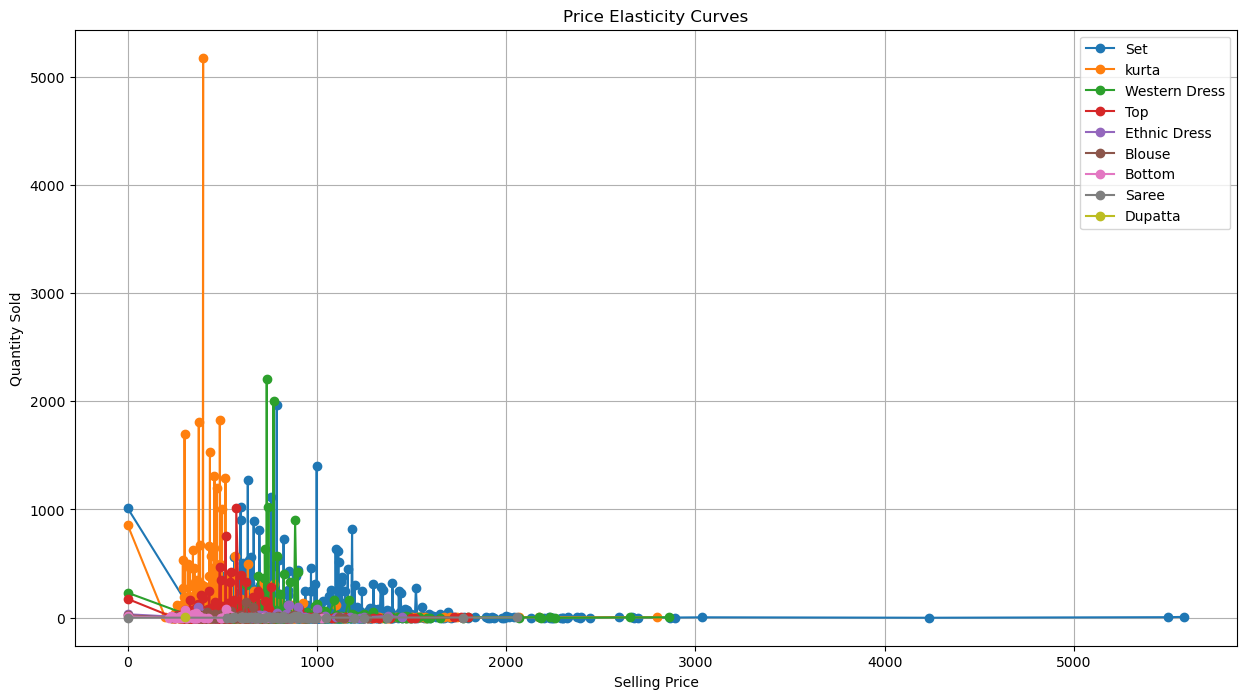

In [28]:
plt.figure(figsize=(15,8))
for cat in top10_list:

    temp = elasticity[
        elasticity["category"] == cat
    ]
    temp = (

        temp.groupby("amount")

        ["qty"]

        .sum()
    )

    plt.plot(

        temp.index,

        temp.values,

        marker="o",

        label=cat

    )

plt.title("Price Elasticity Curves")

plt.xlabel("Selling Price")

plt.ylabel("Quantity Sold")

plt.legend()

plt.grid(True)

plt.show()

In [29]:
asp.to_csv( "../data/processed/average_selling_price.csv",index=False)
print("Export Completed Successfully")

Export Completed Successfully
